# 0. Load Data

## 0.1 Load Data

In [1]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-16-02") 
run_dir = os.path.join("..", "..", "outputs", "run-25-09-13-18")  # RNA-seq
output_dir = os.path.join(run_dir, "outputs")
com_tsv_path = "/aloy/home/ddalton/databases/HuDiNe/AllNet5.tsv"
embedding_type = "ft"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json
with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded variable predictions_test
Loaded variable labels_test
Loaded variable results_test
Loaded variable all_outputs_test
Loaded variable predictions_valid
Loaded variable labels_valid
Loaded variable results_valid
Loaded variable all_outputs_valid
Loaded variable predictions_train
Loaded variable labels_train
Loaded variable results_train
Loaded variable all_outputs_train
Loaded variable adata_orig
Loaded variable id2type
Loaded variable train_indices
Loaded variable valid_indices
Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT

In [2]:
split_idx = 0

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

## 0.2 Load Comorbidity Pairs

In [3]:
import ast
# load do graph
do_graph = ut.load_do_graph()

# map doid to term
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

# map doid to icd
doid_to_icd = dict()
for node, data in do_graph.nodes(data=True):
    for ref in data.get("xref", []):
        if ref.startswith("ICD9CM:"):
            icd = ref.split(":")[1]
            doid_to_icd[node] = icd

# map icd to doid
icd_to_doid = {v: k for k, v in doid_to_icd.items()}

# load comorbidity pairs
df_com = pd.read_csv(com_tsv_path, sep="\t", dtype=str).rename(columns=lambda c: c.strip())
print(f"Loaded {df_com.shape[0]} comorbidity pairs")

# map comorbidity ICD pairs to DOID
df_com["doid_1"] = df_com["#icd9-1"].map(icd_to_doid)
df_com["doid_2"] = df_com["icd9-2"].map(icd_to_doid)
df_com["name_1"] = df_com["doid_1"].map(doid_to_term)
df_com["name_2"] = df_com["doid_2"].map(doid_to_term)

# drop all rows with NA doid
df_com.dropna(subset=["doid_1", "doid_2"], how="any", inplace=True)
print(f"Mapped to {df_com.shape[0]} comorbidity pairs with DOID")

# filter down to those present in our data
_all_doids = list(adata_train.obs["doid_id"].unique())
df_com = df_com.query("doid_1 in @_all_doids and doid_2 in @_all_doids")
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with DOID present in data")

# create sorted pair column
df_com["pair_sorted"] = df_com.apply(lambda row: str(tuple(sorted([row["doid_1"], row["doid_2"]]))), axis=1)

# fix column formats
df_com["n.common"] = df_com["n.common"].astype(int)
df_com["RR"] = df_com["RR"].astype(float)
df_com["pair_sorted"] = df_com["pair_sorted"].apply(ast.literal_eval)


Loaded 6088553 comorbidity pairs
Mapped to 225744 comorbidity pairs with DOID
Filtered to 446 comorbidity pairs with DOID present in data


In [4]:
df_com

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
141542,030,428.0,2,2343516,1,2.781935,0.20662424488693,37.4552459363983,0.00032667643131433,0.500093951541559,DOID:1024,DOID:6000,leprosy,congestive heart failure,"(DOID:1024, DOID:6000)"
141556,030,564.1,2,68078,1,95.765284,7.11276381321136,1289.37074936821,0.00268880635527155,0.701549162774235,DOID:1024,DOID:9778,leprosy,irritable bowel syndrome,"(DOID:1024, DOID:9778)"
624179,135,154.1,6908,43013,11,0.482709,0.220409106339276,1.05716184546206,-0.00068517032797409,-0.142098148439253,DOID:11335,DOID:1993,sarcoidosis,rectum cancer,"(DOID:11335, DOID:1993)"
624238,135,183.0,6908,27393,12,0.826864,0.39036641594227,1.75144281350818,-0.000182898283583849,-0.0302700808586769,DOID:11335,DOID:2394,sarcoidosis,ovarian cancer,"(DOID:11335, DOID:2394)"
624347,135,203.0,6908,7923,9,2.144102,0.9012745077071,5.10074639866493,0.000649513006733088,0.0578066697926136,DOID:11335,DOID:9538,sarcoidosis,multiple myeloma,"(DOID:11335, DOID:9538)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.9486709219018,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"
5399494,710.2,720.0,6892,6375,32,9.496628,5.99735352551419,15.0376218924225,0.00432150903489894,0.358714631731391,DOID:12894,DOID:7147,Sjogren's syndrome,ankylosing spondylitis,"(DOID:12894, DOID:7147)"
5423569,714.0,720.0,175906,6375,1506,17.510922,16.3762914745442,18.7241654278765,0.0427034018104937,17.9265483791382,DOID:7148,DOID:7147,rheumatoid arthritis,ankylosing spondylitis,"(DOID:7147, DOID:7148)"
5424127,714.0,758.7,175906,149,4,1.989931,0.54231954720795,7.30164393965983,0.000391331918484729,0.164128183490042,DOID:7148,DOID:1921,rheumatoid arthritis,Klinefelter syndrome,"(DOID:1921, DOID:7148)"


In [5]:
df_com

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
141542,030,428.0,2,2343516,1,2.781935,0.20662424488693,37.4552459363983,0.00032667643131433,0.500093951541559,DOID:1024,DOID:6000,leprosy,congestive heart failure,"(DOID:1024, DOID:6000)"
141556,030,564.1,2,68078,1,95.765284,7.11276381321136,1289.37074936821,0.00268880635527155,0.701549162774235,DOID:1024,DOID:9778,leprosy,irritable bowel syndrome,"(DOID:1024, DOID:9778)"
624179,135,154.1,6908,43013,11,0.482709,0.220409106339276,1.05716184546206,-0.00068517032797409,-0.142098148439253,DOID:11335,DOID:1993,sarcoidosis,rectum cancer,"(DOID:11335, DOID:1993)"
624238,135,183.0,6908,27393,12,0.826864,0.39036641594227,1.75144281350818,-0.000182898283583849,-0.0302700808586769,DOID:11335,DOID:2394,sarcoidosis,ovarian cancer,"(DOID:11335, DOID:2394)"
624347,135,203.0,6908,7923,9,2.144102,0.9012745077071,5.10074639866493,0.000649513006733088,0.0578066697926136,DOID:11335,DOID:9538,sarcoidosis,multiple myeloma,"(DOID:11335, DOID:9538)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.9486709219018,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"
5399494,710.2,720.0,6892,6375,32,9.496628,5.99735352551419,15.0376218924225,0.00432150903489894,0.358714631731391,DOID:12894,DOID:7147,Sjogren's syndrome,ankylosing spondylitis,"(DOID:12894, DOID:7147)"
5423569,714.0,720.0,175906,6375,1506,17.510922,16.3762914745442,18.7241654278765,0.0427034018104937,17.9265483791382,DOID:7148,DOID:7147,rheumatoid arthritis,ankylosing spondylitis,"(DOID:7147, DOID:7148)"
5424127,714.0,758.7,175906,149,4,1.989931,0.54231954720795,7.30164393965983,0.000391331918484729,0.164128183490042,DOID:7148,DOID:1921,rheumatoid arthritis,Klinefelter syndrome,"(DOID:1921, DOID:7148)"


In [6]:
_df_com_100 = df_com[df_com["n.common"]>100]
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with >100 common patients")

_df_com_100["pval.adj"] = _df_com_100["pval.adj"].astype(float)

for rr_i in [1, 2, 5, 10]:
    # _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)& (_df_com_100["pval.adj"]<=0.05)]
    _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)]
    print(f"Filtered to {_df_q.shape[0]} comorbidity pairs with RR>{rr_i}")


Filtered to 446 comorbidity pairs with >100 common patients
Filtered to 64 comorbidity pairs with RR>1
Filtered to 22 comorbidity pairs with RR>2
Filtered to 8 comorbidity pairs with RR>5
Filtered to 6 comorbidity pairs with RR>10


/tmp/ipykernel_9699/149838223.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_com_100["pval.adj"] = _df_com_100["pval.adj"].astype(float)


In [7]:
_df_com_100

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
625298,135,428.0,6908,2343516,1598,1.287068,1.20602987919301,1.37355087049508,0.00309375967585099,4.736117,DOID:11335,DOID:6000,sarcoidosis,congestive heart failure,"(DOID:11335, DOID:6000)"
625615,135,530.1,6908,425051,281,1.247837,1.06855998430711,1.45719194072175,0.00104744080336909,0.682888,DOID:11335,DOID:11963,sarcoidosis,esophagitis,"(DOID:11335, DOID:11963)"
626108,135,714.0,6908,175906,113,1.212524,0.949441678890986,1.54850424434395,0.000572195047091499,0.239984,DOID:11335,DOID:7148,sarcoidosis,rheumatoid arthritis,"(DOID:11335, DOID:7148)"
764842,154.1,331.0,43013,229250,446,0.589754,0.52144072809095,0.667016198345224,-0.00315735676807998,-1.511745,DOID:1993,DOID:10652,rectum cancer,Alzheimer's disease,"(DOID:10652, DOID:1993)"
765430,154.1,428.0,43013,2343516,5968,0.771980,0.74644229262584,0.7983913931767,-0.00614046515315821,-9.400333,DOID:1993,DOID:6000,rectum cancer,congestive heart failure,"(DOID:1993, DOID:6000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396848,710.0,714.0,21900,175906,1552,5.253054,4.91759648253813,5.61139419034205,0.0204001234539712,8.557778,DOID:9074,DOID:7148,systemic lupus erythematosus,rheumatoid arthritis,"(DOID:7148, DOID:9074)"
5398321,710.1,710.2,7661,6892,215,53.094876,44.4677615634985,63.3957229813574,0.0290474438305915,2.543181,DOID:418,DOID:12894,systemic scleroderma,Sjogren's syndrome,"(DOID:12894, DOID:418)"
5398353,710.1,714.0,7661,175906,349,3.376791,2.93807552039684,3.88101604314279,0.00673916711672044,2.826532,DOID:418,DOID:7148,systemic scleroderma,rheumatoid arthritis,"(DOID:418, DOID:7148)"
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.948671,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"


In [8]:
# _df_com_100 = df_com[df_com["n.common"]>100]
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with >100 common patients")


for rr_i in [1, 2, 5, 10]:
    _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)& (_df_com_100["pval.adj"]<2)]
    print(f"Filtered to {_df_q.shape[0]} comorbidity pairs with RR>{rr_i}")


Filtered to 446 comorbidity pairs with >100 common patients
Filtered to 30 comorbidity pairs with RR>1
Filtered to 6 comorbidity pairs with RR>2
Filtered to 0 comorbidity pairs with RR>5
Filtered to 0 comorbidity pairs with RR>10


In [9]:
_df_com_100[(_df_com_100["RR"]>1)]

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
625298,135,428.0,6908,2343516,1598,1.287068,1.20602987919301,1.37355087049508,0.00309375967585099,4.736117,DOID:11335,DOID:6000,sarcoidosis,congestive heart failure,"(DOID:11335, DOID:6000)"
625615,135,530.1,6908,425051,281,1.247837,1.06855998430711,1.45719194072175,0.00104744080336909,0.682888,DOID:11335,DOID:11963,sarcoidosis,esophagitis,"(DOID:11335, DOID:11963)"
626108,135,714.0,6908,175906,113,1.212524,0.949441678890986,1.54850424434395,0.000572195047091499,0.239984,DOID:11335,DOID:7148,sarcoidosis,rheumatoid arthritis,"(DOID:11335, DOID:7148)"
1241142,203.0,428.0,7923,2343516,2225,1.562490,1.47871044688966,1.65101683429132,0.00649236250604639,9.939069,DOID:9538,DOID:6000,multiple myeloma,congestive heart failure,"(DOID:6000, DOID:9538)"
1241462,203.0,530.1,7923,425051,300,1.161543,0.999642079031242,1.34966614350997,0.000731203509492823,0.476714,DOID:9538,DOID:11963,multiple myeloma,esophagitis,"(DOID:11963, DOID:9538)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396848,710.0,714.0,21900,175906,1552,5.253054,4.91759648253813,5.61139419034205,0.0204001234539712,8.557778,DOID:9074,DOID:7148,systemic lupus erythematosus,rheumatoid arthritis,"(DOID:7148, DOID:9074)"
5398321,710.1,710.2,7661,6892,215,53.094876,44.4677615634985,63.3957229813574,0.0290474438305915,2.543181,DOID:418,DOID:12894,systemic scleroderma,Sjogren's syndrome,"(DOID:12894, DOID:418)"
5398353,710.1,714.0,7661,175906,349,3.376791,2.93807552039684,3.88101604314279,0.00673916711672044,2.826532,DOID:418,DOID:7148,systemic scleroderma,rheumatoid arthritis,"(DOID:418, DOID:7148)"
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.948671,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"


## 0.3 Load Disease Ontology Pairs

In [10]:
"""0.3 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)


df_train = adata_train.obs.copy()
df_test = adata_test.obs.copy()
df_valid = adata_valid.obs.copy()

df_all = pd.concat([df_train, df_valid, df_test], axis=0)
df_all = df_all.query("doid_id != 'Control'")

dsaid_2_dis = dict(zip(df_all["dsaid"], df_all["doid_id"]))


Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [11]:
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

In [24]:
_do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")

# map disease disease -> lin
dis_2_lin = dict()
for _,r in _do_df_ic_query.iterrows():
    d1 = r["do1"]
    d2 = r["do2"]
    lin = r["lin"]
    if d1 not in dis_2_lin.keys():
        dis_2_lin[d1] = dict()
    if d2 not in dis_2_lin.keys():
        dis_2_lin[d2] = dict()
    
    dis_2_lin[d1][d2] = lin
    dis_2_lin[d2][d1] = lin

In [30]:
# get for each pair LIN similarity
_lin_vals = list()
for _,r in _df_com_100.iterrows():
    d1 = r["doid_1"]
    d2 = r["doid_2"]
    lin = dis_2_lin[d1][d2]
    _lin_vals.append(lin)

_df_com_100 = _df_com_100.copy()
_df_com_100["lin"] = _lin_vals

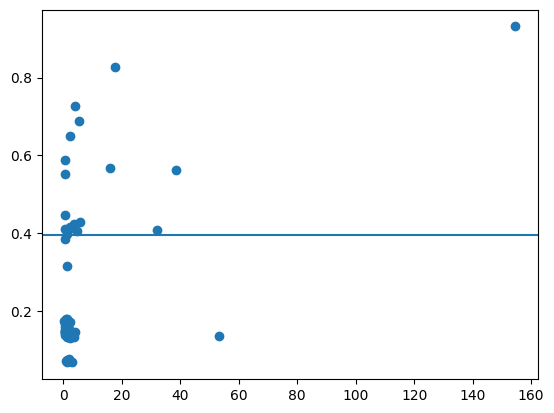

In [34]:
plt.scatter(_df_com_100["RR"], _df_com_100["lin"])
plt.axhline(0.396)

# 1. Compute Similarity


In [12]:
"""Here we will evaluate the Embeddings
Analyze how well the embeddings capture same disease as well as related diseases
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable


# functions

# 2. Load Data

# load embeddings
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])

elif embedding_type == "raw":
    embeddings_test = adata_test.X
    embeddings_valid = adata_valid.X
    embeddings_train = adata_train.X

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

elif embedding_type == "raw_normed":
    embeddings_test = adata_test.layers["X_normed"]
    embeddings_valid = adata_valid.layers["X_normed"]
    embeddings_train = adata_train.layers["X_normed"]

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)


# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "cosine")
c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "cosine")
c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "cosine")

# compute cosine similarity between sets
c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, "cosine")
c_matrix_valid_vs_train = 1 - cdist(embeddings_valid, embeddings_train, "cosine")



In [50]:
import importlib
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

In [13]:
np.sum(np.sum(embeddings_valid,axis=1) == 0)

np.int64(0)

In [14]:
np.isnan(embeddings_train).sum()

np.int64(0)

# 2. Benchmark Comorbidities

In [ ]:
# imports 
from matplotlib.ticker import EngFormatter
import random

# variables

# functions

def get_com_sim(
    adata_qry, adata_ref, RR_thrs, c_matrix, df_com,  sample:int=10000000
):
    fmt = EngFormatter(places=1)
   
   # select datasets & do_ids
    do_ids_qry = adata_qry.obs["do_id"].values
    datasets_qry = adata_qry.obs["dataset"].values

    do_ids_ref = adata_ref.obs["do_id"].values
    datasets_ref = adata_ref.obs["dataset"].values

    c_all = list()
    w_all = list()
    l_all = list()
    _sample_sizes = list()
    
    # get related pairs
    for thr in RR_thrs:
        _df_com = df_com.query("RR>@thr")
        print(f"Filtering to {len(_df_com)} comorbidity pairs with RR>{thr}")
        if len(_df_com)==0:
            continue
        related_idxs, _l_related = vz.get_doid_idxs_pairs_split(list(_df_com["pair_sorted"]), do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)
        print(f"Nº of comorbidity disease pairs : {len(related_idxs)}")

        # convert label to weights - all pairs add to 1
        _w_related = vz._convert_labels_to_weights(_l_related)

        if sample & (len(related_idxs) > sample):
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        # retrieve similarities
        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # append values
        c_all.append(_c_related)
        w_all.append(_w_related)
        _sample_sizes.append(len(_c_related))

        # append labels
        l_all.append(f"Comorbidities RR +{thr} | {len(_df_com)} pairs | {fmt(len(_c_related))} comps",)

    return c_all, w_all, l_all


# define related and unrelated dataframes
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# get similarity of unrelated diseases
ts_s_unr,_,_ =vz.get_unrelated_pairs_split_2(adata_test, adata_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)
vl_s_unr,_,_ = vz.get_unrelated_pairs_split_2(adata_valid, adata_train, c_matrix_valid_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=10000,
    seed=42,
)

# get comorbidity similarities
c_com_train, w_com_train, l_com_train = get_com_sim(
    adata_train, adata_train, [1,1.5,2,5,10], c_matrix_train, _df_com_100, sample=10000000
)
c_com_valid, w_com_valid, l_com_valid = get_com_sim(
    adata_valid, adata_train, [1,1.5,2,5,10], c_matrix_valid_vs_train, _df_com_100, sample=10000000
)
c_com_test, w_com_test, l_com_test = get_com_sim(
    adata_test, adata_train, [1,1.5, 2, 5, 10], c_matrix_test_vs_train, _df_com_100, sample=10000000
)

100%|██████████| 6586/6586 [00:35<00:00, 184.89it/s]


124 diseases in dataset


7626it [00:18, 409.57it/s]


130783999 unrelated pairs found
10000
Selected 10000 unrelated pairs
Sampled pairs: 10000


TypeError: get_com_sim() got an unexpected keyword argument 'dpi'

In [38]:
_df_com_100_q = _df_com_100.query("lin <=0.396")

# get comorbidity similarities
c_com_train, w_com_train, l_com_train = get_com_sim(
    adata_train, adata_train, [1,1.5,2,5,10], c_matrix_train, _df_com_100_q, sample=10000000
)
c_com_valid, w_com_valid, l_com_valid = get_com_sim(
    adata_valid, adata_train, [1,1.5,2,5,10], c_matrix_valid_vs_train, _df_com_100_q, sample=10000000
)
c_com_test, w_com_test, l_com_test = get_com_sim(
    adata_test, adata_train, [1,1.5, 2, 5, 10], c_matrix_test_vs_train, _df_com_100_q, sample=10000000


)

Filtering to 50 comorbidity pairs with RR>1


100%|██████████| 50/50 [00:00<00:00, 80.57it/s]


Nº of comorbidity disease pairs : 379130
Filtering to 19 comorbidity pairs with RR>1.5


100%|██████████| 19/19 [00:00<00:00, 82.95it/s]


Nº of comorbidity disease pairs : 182672
Filtering to 9 comorbidity pairs with RR>2


...

Nº of comorbidity disease pairs : 31296
Filtering to 1 comorbidity pairs with RR>5


100%|██████████| 1/1 [00:00<00:00, 1349.52it/s]


Nº of comorbidity disease pairs : 324
Filtering to 1 comorbidity pairs with RR>10


100%|██████████| 1/1 [00:00<00:00, 1402.78it/s]

Nº of comorbidity disease pairs : 324


In [42]:
def get_bins(vals):
    labels = []
    for v in vals:
        if 1 <= v < 1.5:
            lab = "1-1.5 RR"
        elif 1.5 <= v < 2:
            lab = "1.5-2 RR"
        elif 2 <= v < 5:
            lab = "2-5 RR"
        elif 5 <= v < 10:
            lab = "5-10 RR"
        elif v >= 10:
            lab = "10+ RR"
        else:
            lab = 0  # or None, depending on what you prefer
        labels.append(lab)
    return labels


# bin data based on similarity
_df_com_100 = _df_com_100.copy()
_df_com_100["shortest_path_length"] = get_bins(_df_com_100["RR"].values)


# bin data based on similarity
_df_com_100_q = _df_com_100_q.copy()
_df_com_100_q["shortest_path_length"] = get_bins(_df_com_100_q["RR"].values)


In [52]:
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

In [53]:
_bin_labels = ["'1-1.5 RR'","'1.5-2 RR'","'2-5 RR'","'5-10 RR'","'10+ RR'"]
sample_size = 1000



# train
tr_s_all_1, tr_w_all_1, tr_l_all_1 = vz.get_related_dis_sim(
    adata_train, c_matrix_train, _df_com_100_q, df_unrelated, labels=_bin_labels, sample=sample_size,
)

# valid
vl_s_all_1, vl_w_all_1, vl_l_all_1 = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train, _df_com_100_q, df_unrelated, labels=_bin_labels, sample=sample_size)

# test
ts_s_all_1, ts_w_all_1, ts_l_all_1 = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train, _df_com_100_q, df_unrelated, labels=_bin_labels, sample=sample_size)


100%|██████████| 6586/6586 [00:01<00:00, 3868.04it/s]


Nº of unrelated disease pairs: 54147313
[SP '1-1.5 RR'] Nº of related disease pairs: 31


100%|██████████| 31/31 [00:00<00:00, 270.38it/s]


Nº of related disease pairs for '1-1.5 RR': 98229
[SP '1.5-2 RR'] Nº of related disease pairs: 10


100%|██████████| 10/10 [00:00<00:00, 112.59it/s]


...

Nº of related disease pairs for '5-10 RR': 0
[SP '10+ RR'] Nº of related disease pairs: 1


100%|██████████| 1/1 [00:00<00:00, 1385.17it/s]


Nº of related disease pairs for '10+ RR': 324
Nº of diseases: 123


100%|██████████| 123/123 [00:00<00:00, 379.06it/s]


Nº of unrelated disease pairs: 125095


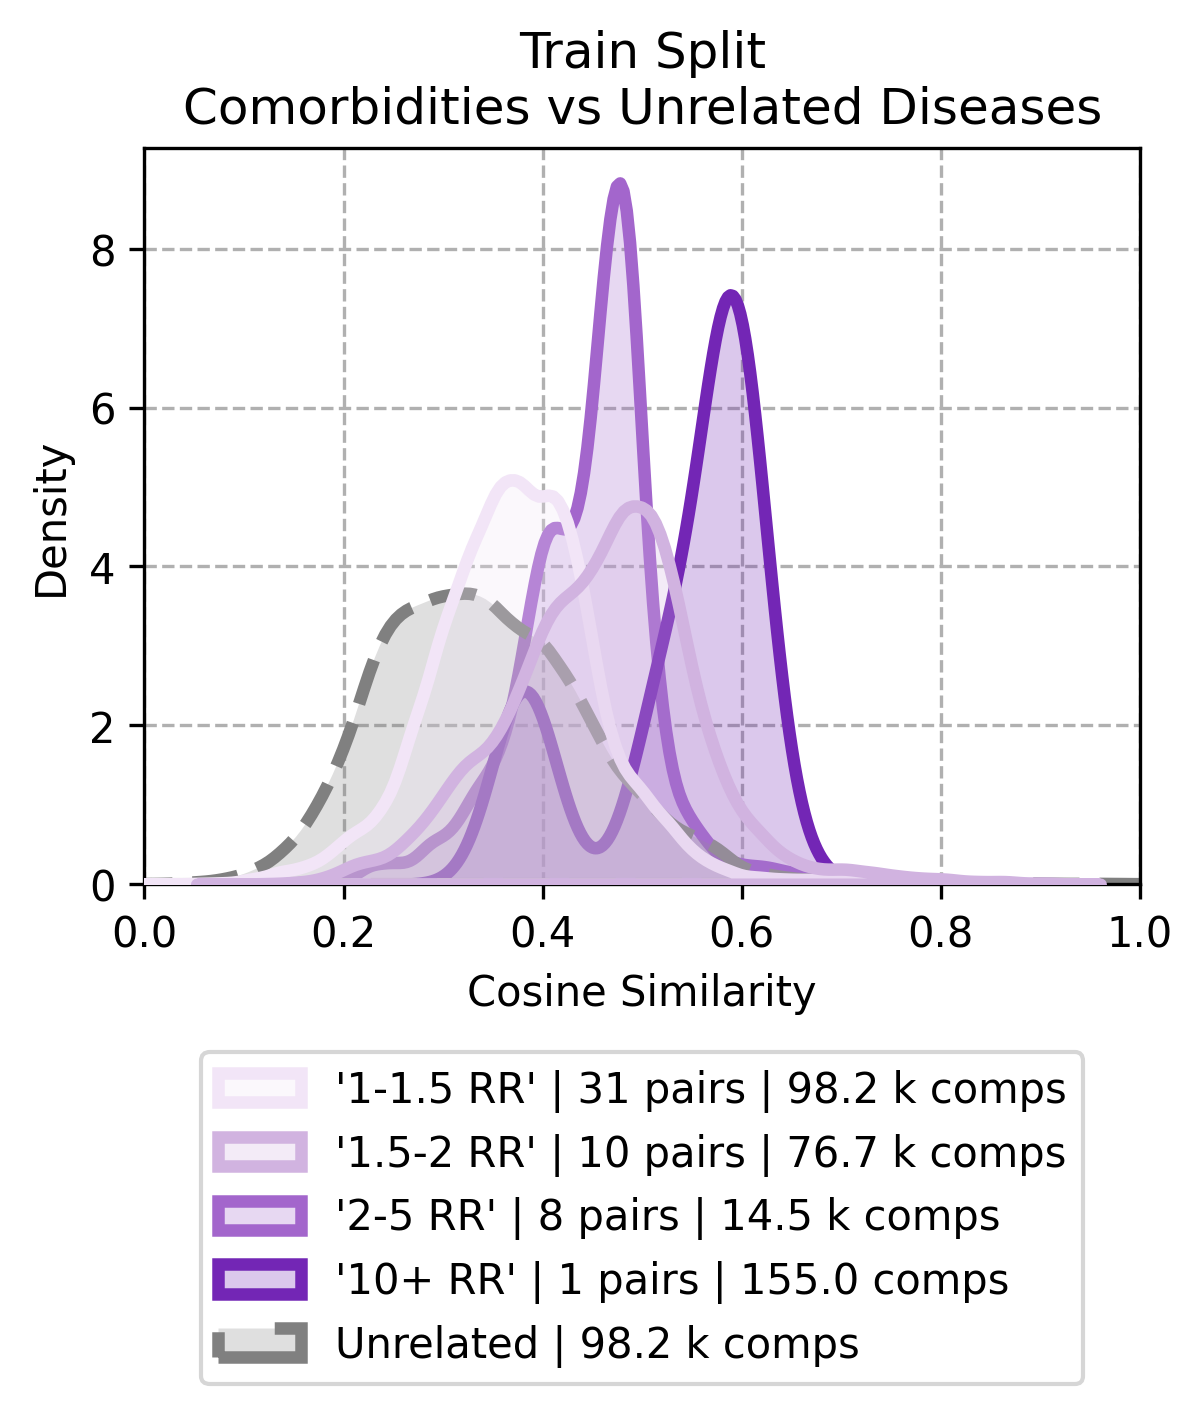

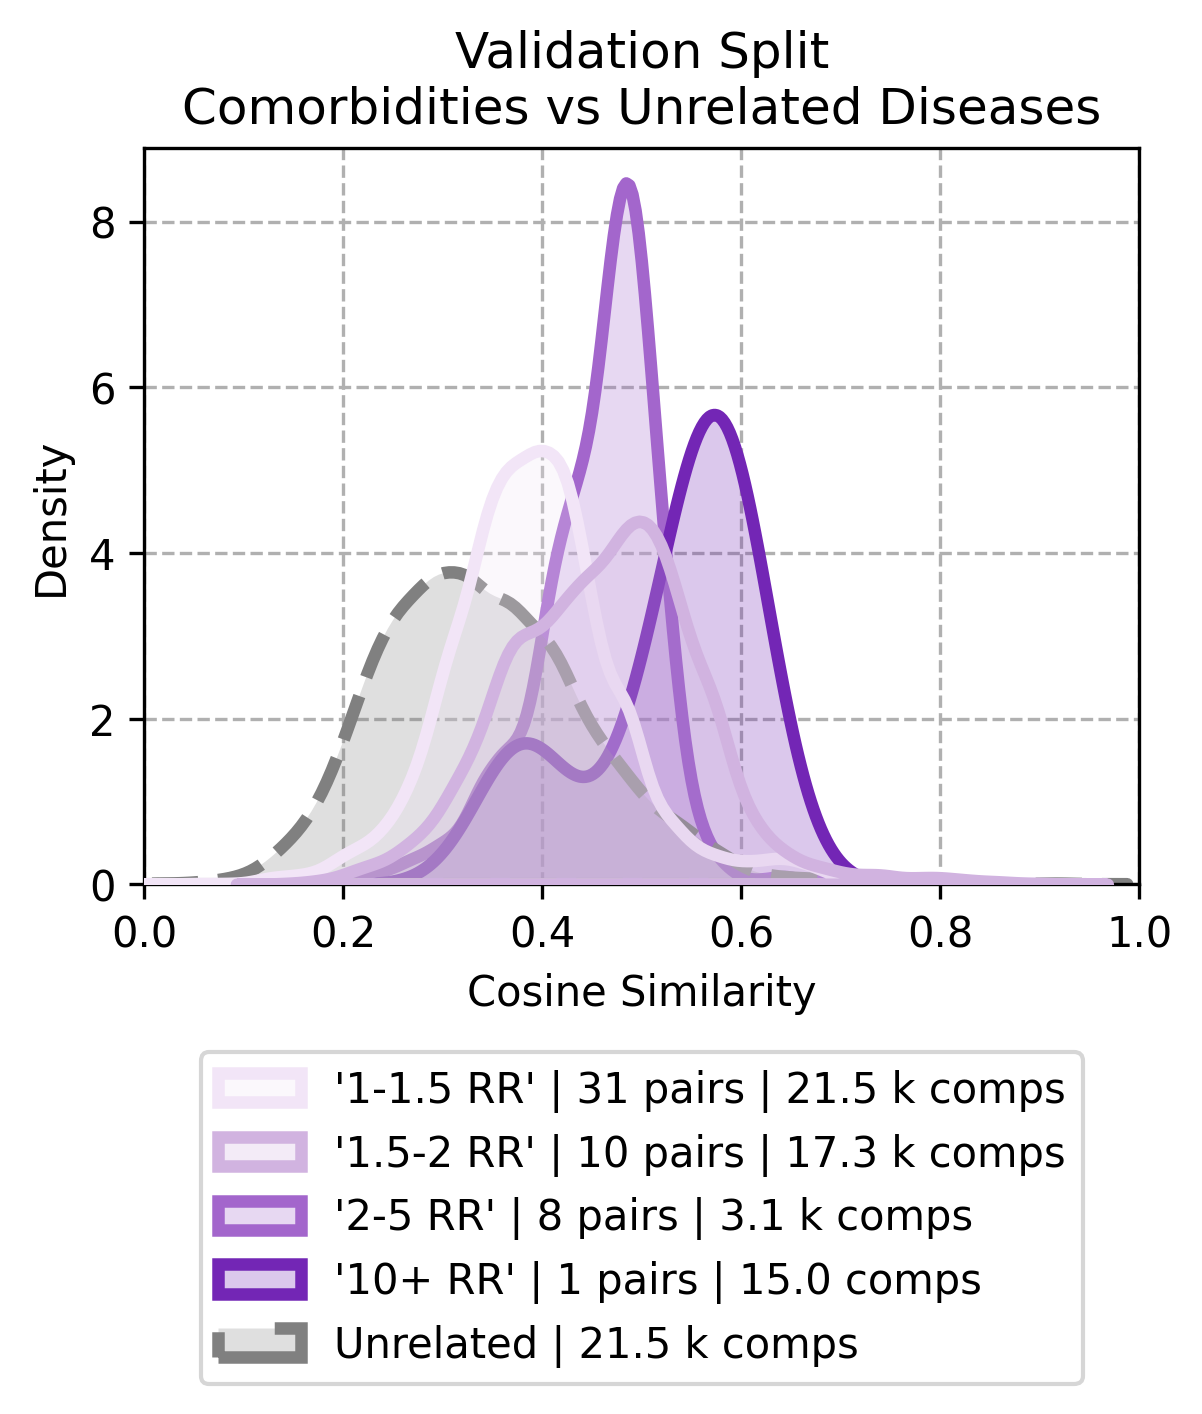

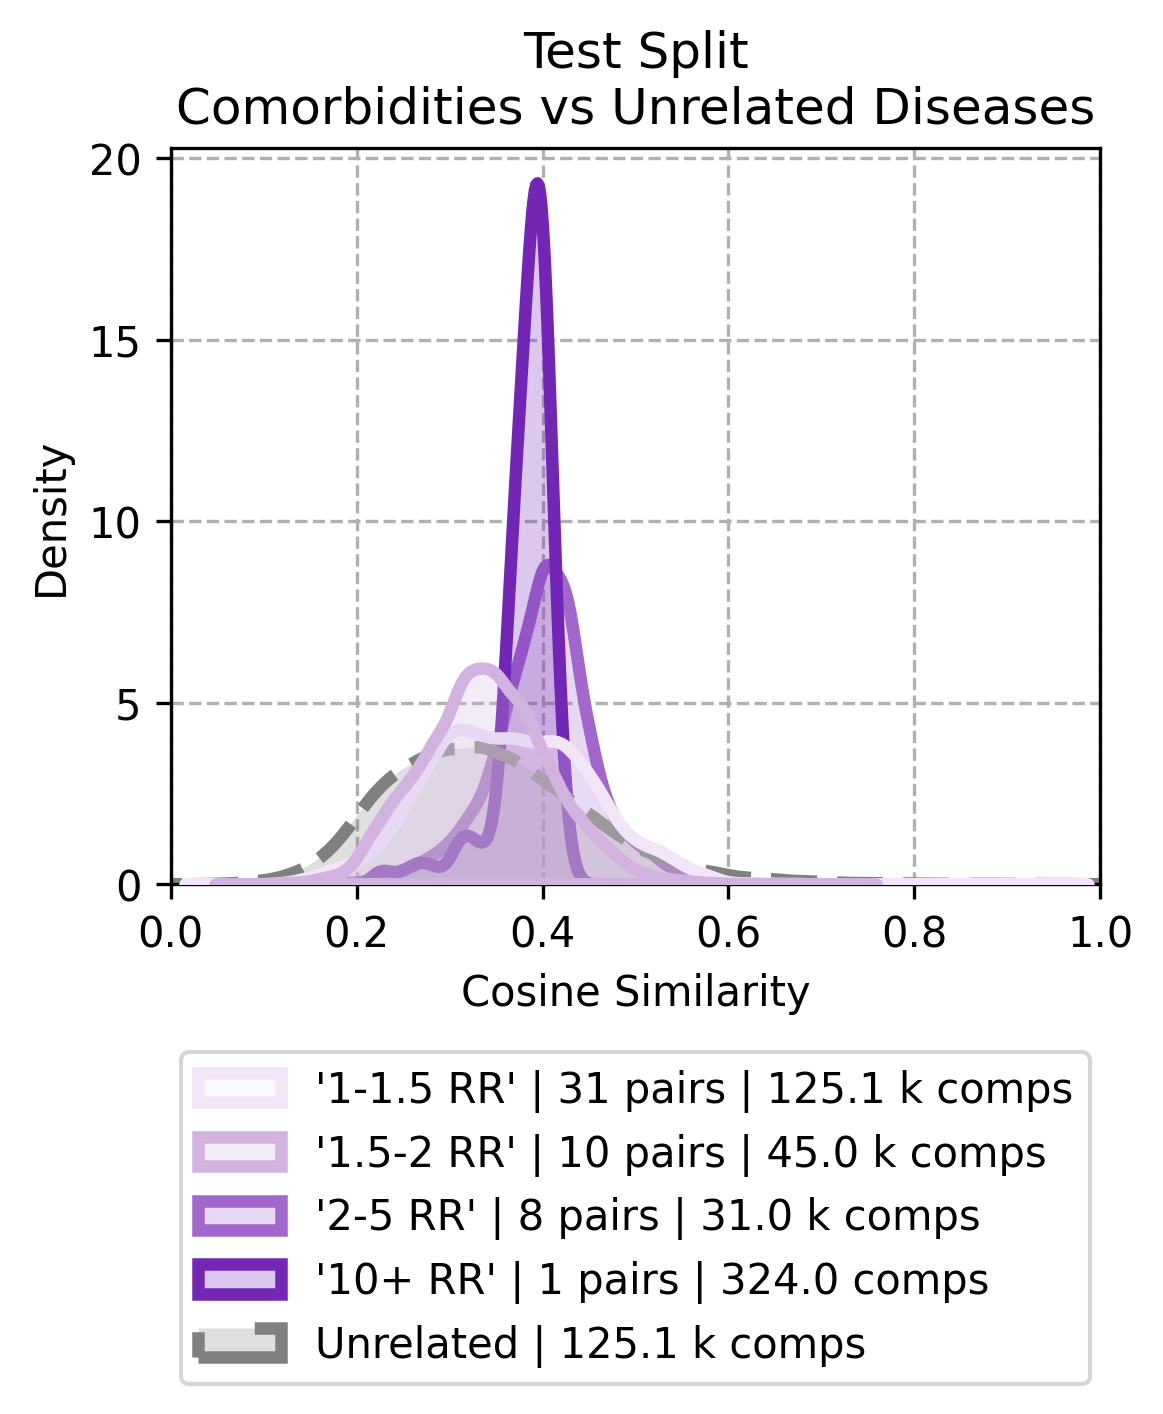

In [54]:
purple_scale = ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"]


vz.plot_kde(tr_s_all_1[:-2] + [tr_s_all_1[-1]], 
            labels=tr_l_all_1[:-2] + [tr_l_all_1[-1]]   ,
            title="Train Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = 1000000,   
            metric="Cosine Similarity")

vz.plot_kde(vl_s_all_1[:-2] + [vl_s_all_1[-1]], 
            labels=vl_l_all_1[:-2] + [vl_l_all_1[-1]]   ,
            title="Validation Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = 1000000,   
            metric="Cosine Similarity")

vz.plot_kde(ts_s_all_1[:-2] + [ts_s_all_1[-1]], 
            labels=ts_l_all_1[:-2] + [ts_l_all_1[-1]]   ,
            title="Test Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = 1000000,   
            metric="Cosine Similarity")

In [ ]:
# c_com_train, w_com_train, l_com_train = get_com_sim(
#     adata_train, adata_train, [1,1.5,2,5,10], c_matrix_train, _df_com_100, sample=10000000
# )
# c_com_valid, w_com_valid, l_com_valid = get_com_sim(
#     adata_valid, adata_train, [1,1.5,2,5,10], c_matrix_valid_vs_train, _df_com_100, sample=10000000
# )
# c_com_test, w_com_test, l_com_test = get_com_sim(
#     adata_test, adata_train, [1,1.5, 2, 5, 10], c_matrix_test_vs_train, _df_com_100, sample=10000000
# )

In [ ]:
# purple_scale = ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"]

# vz.plot_kde(c_com_train + [tr_s_unr], 
#             labels=l_com_train + ["Unrelated Diseases | Sampled 10,000 pairs"],
#             title="Train Split\nComorbidities vs Unrelated Diseases",
#             colors=purple_scale + ["grey"] ,
#             weights = None,
#             sample = 1000000,   
#             metric="Cosine Similarity")

# vz.plot_kde(c_com_valid + [vl_s_unr], 
#             labels=l_com_valid + ["Unrelated Diseases | Sampled 10,000 pairs"],
#             title="Validation Split\nComorbidities vs Unrelated Diseases",
#             colors=purple_scale + ["grey"] ,
#             weights = None,
#             sample = 1000000,
#             metric="Cosine Similarity")


# vz.plot_kde(c_com_test + [ts_s_unr], 
#             labels=l_com_test + ["Unrelated Diseases | Sampled 10,000 pairs"],
#             title="Test Split\nComorbidities vs Unrelated Diseases",
#             colors=purple_scale + ["grey"] ,
#             sample= 1000000,
#             weights = None,
#             metric="Cosine Similarity")

In [ ]:
dpi = 300
# vz.plot_roc(tr_s_all_1[:-1], [tr_s_unr], labels=tr_l_all_1, title="Train Split\nAUROC", colors=purple_scale, w_pos=None,sample=sample_size,dpi=100)
vz.plot_roc(tr_s_all_1[:-2], tr_s_all_1[-1], labels=tr_l_all_1[:-2], title="Train Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=sample_size,dpi=dpi)
vz.plot_roc(vl_s_all_1[:-2], vl_s_all_1[-1], labels=vl_l_all_1[:-2], title="Validation Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=sample_size,dpi=dpi)
vz.plot_roc(ts_s_all_1[:-2], ts_s_all_1[-1], labels=ts_l_all_1[:-2], title="Test Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=sample_size,dpi=dpi)



Nº of positive disease pairs: 98922
Nº of positive disease pairs: 1000


ValueError: Input contains NaN.

<Figure size 1200x1200 with 0 Axes>

In [ ]:
np.sum(np.isnan(tr_s_all_1[0]))

np.int64(1352)

In [ ]:
len(tr_s_all_1)

7

In [ ]:
tr_s_unr

[np.float64(0.2682886747683899),
 np.float64(0.32825303134943007),
 np.float64(0.2685507325874843),
 np.float64(0.4428925152243719),
 np.float64(0.242291622450026),
 np.float64(0.2672136788968569),
 np.float64(0.34572191752312353),
 np.float64(0.15152965503940996),
 np.float64(0.2814254356812168),
 np.float64(0.44084190335837936),
 np.float64(0.2097944361683719),
 np.float64(0.40350761088522813),
 np.float64(0.3193397684768171),
 np.float64(0.5517695910836146),
 np.float64(0.4211872166481101),
 np.float64(0.28150759927150926),
 np.float64(0.16757085368237556),
 np.float64(0.36411094272732814),
 np.float64(0.5422000232755676),
 np.float64(0.41574625207615723),
 np.float64(0.5769001370859622),
 np.float64(0.2385186405353995),
 np.float64(0.2653828168343495),
 np.float64(0.32700597696546985),
 np.float64(0.3790890170035145),
 np.float64(0.4315137673805196),
 np.float64(0.4773400943143803),
 np.float64(0.3984388243297594),
 np.float64(0.37224788938290987),
 np.float64(0.3501479700909427),


In [ ]:
tr_l_all_1

["'1-1.5 RR' | 32 pairs | 98.9 k comps",
 "'1.5-2 RR' | 10 pairs | 76.7 k comps",
 "'2-5 RR' | 14 pairs | 22.5 k comps",
 "'5-10 RR' | 2 pairs | 104.2 k comps",
 "'10+ RR' | 6 pairs | 19.5 k comps",
 'Same Disease | 123 dis | 1.1 M comps',
 'Unrelated | 104.2 k comps']

In [ ]:
import random
import tqdm
from scanpy import AnnData as Anndata

def get_comorb_per_dis(adata_qry:Anndata, adata_ref:Anndata, df_related:pd.DataFrame, df_unrelated:pd.DataFrame, c_matrix:np.ndarray, doid_to_term:dict)->pd.DataFrame:
    results_per_dis = list()
    for doid_i in tqdm(adata_qry.obs["doid_id"].unique()):
        if doid_i == "Control":
            continue
        # get related & unrelated diseases
        related_i = set(df_related.query(f"do1 == '{doid_i}'")["do2"].values)
        related_i = related_i.union(set(df_related.query(f"do2 == '{doid_i}'")["do1"].values))
        related_i = list(related_i)

        unrelated_i = set(df_unrelated.query(f"do1 == '{doid_i}'")["do2"].values)
        unrelated_i = unrelated_i.union(set(df_unrelated.query(f"do2 == '{doid_i}'")["do1"].values))
        unrelated_i = list(unrelated_i)

        # get idxs
        idx_1 = np.array(adata_qry.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # query disease
        idx_2 = np.array(adata_ref.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # reference disease
        idx_3 = np.array(adata_ref.obs.query(f"(doid_id in @related_i)").index).astype(int)  # reference unrelated diseases
        idx_4 = np.array(adata_ref.obs.query(f"(doid_id in @unrelated_i)").index).astype(int)  # reference unrelated diseases
        dsaids = adata_ref.obs.query(f"(doid_id in @unrelated_i)")["dsaid"].unique()
        idx_5 = np.array(adata_ref.obs.query(f"(dsaid in @dsaids)").index).astype(int)  # reference unrelated diseases

        if len(idx_1) == 0 or len(idx_2) == 0 or len(idx_5) == 0:
            print(f"Skipping {doid_i} - {doid_to_term.get(doid_i)} due to lack of pairs")
            print(f"Nº same: {len(idx_2)}\tNº unrelated: {len(idx_5)}")
            continue
        
        idx_pairs_1 = np.array(list(itertools.product(idx_1, idx_2)))
        idx_pairs_2 = np.array(list(itertools.product(idx_1, idx_5)))

        _s_same = c_matrix[idx_pairs_1[:, 0], idx_pairs_1[:, 1]]
        _s_unrelated = c_matrix[idx_pairs_2[:, 0], idx_pairs_2[:, 1]]        

        # results per disease
        ap_i = average_precision_score(
            [1] * len(_s_same) + [0] * (len(_s_unrelated)),
            np.concatenate([_s_same, _s_unrelated])
        )
        random_i = len(_s_same) / (len(_s_same) + len(_s_unrelated)) if (len(_s_same) + len(_s_unrelated)) > 0 else 0
        auroc_i = roc_auc_score(
            [1] * len(_s_same) + [0] * (len(_s_same)),
            np.concatenate([_s_same, np.array(random.sample(list(_s_unrelated), len(_s_same)))])
        )
        
        results_per_dis.append({
            "average_precision": ap_i,
            "roc_auc": auroc_i,
            "random": random_i,
            "disease": doid_to_term.get(doid_i),
            "doid": doid_i,
            "n_positives": len(_s_same),
            "n_unrelated": len(_s_unrelated),
        })

        df_per_dis = pd.DataFrame(results_per_dis)

    return df_per_dis

In [ ]:
import pandas as pd

def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    # both most be same size!
    min_size = min(len(pos), len(neg))
    pos = np.array(pos)
    neg = np.array(neg)

    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc

def comb_make_auroc_row(split_name:str, c_com:np.array, s_unr:np.array, ndigits:int=3):
    return pd.DataFrame({
        "Split": [split_name],
        "Comorbidity 1-1.5 RR": [round(_auroc(c_com[0], s_unr),ndigits=ndigits)],
        "Comorbidity 1.5-2 RR": [round(_auroc(c_com[1], s_unr),ndigits=ndigits)],
        "Comorbidity 2-5 RR": [round(_auroc(c_com[2], s_unr),ndigits=ndigits)],
        "Comorbidity 5-10 RR": [round(_auroc(c_com[3], s_unr),ndigits=ndigits)],
        "Comorbidity +10 RR": [round(_auroc(c_com[4], s_unr),ndigits=ndigits)],
    })


#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING UNRELATED DISEASES & THEIR CONTROLS
# Build each split row
df_auroc_train = comb_make_auroc_row(
    "Train",
    tr_s_all_1[:-2],
    tr_s_all_1[-1]
)

df_auroc_valid = comb_make_auroc_row(
    "Valid",
    vl_s_all_1[:-2],
    vl_s_all_1[-1]
)

df_auroc_test = comb_make_auroc_row(
    "Test",
    ts_s_all_1[:-2],
    ts_s_all_1[-1]
)

# Optional: one tidy table
df_auroc = pd.concat([df_auroc_train, df_auroc_valid, df_auroc_test], ignore_index=True)

df_auroc

Nº of positive disease pairs: 98922
Nº of positive disease pairs: 76718
Nº of positive disease pairs: 22459
Nº of positive disease pairs: 104206
Nº of positive disease pairs: 19535
Nº of positive disease pairs: 21563
Nº of positive disease pairs: 17326
Nº of positive disease pairs: 4788
Nº of positive disease pairs: 23286
Nº of positive disease pairs: 3778
Nº of positive disease pairs: 128341
Nº of positive disease pairs: 45034
Nº of positive disease pairs: 37089
Nº of positive disease pairs: 5951
Nº of positive disease pairs: 16405


,Split,Comorbidity 1-1.5 RR,Comorbidity 1.5-2 RR,Comorbidity 2-5 RR,Comorbidity 5-10 RR,Comorbidity +10 RR
0,Train,0.624,0.401,0.580,0.646,0.662
1,Valid,0.616,0.400,0.598,0.625,0.667
2,Test,0.331,0.242,0.328,0.567,0.489


In [ ]:
import pandas as pd

def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    # both most be same size!
    min_size = min(len(pos), len(neg))
    pos = np.array(pos)
    neg = np.array(neg)

    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc

def comb_make_auroc_row(split_name:str, c_com:np.array, s_unr:np.array, ndigits:int=3):
    return pd.DataFrame({
        "Split": [split_name],
        "Comorbidity +1 RR": [round(_auroc(c_com[0], s_unr),ndigits=ndigits)],
        "Comorbidity +1.5 RR": [round(_auroc(c_com[1], s_unr),ndigits=ndigits)],
        "Comorbidity +2 RR": [round(_auroc(c_com[2], s_unr),ndigits=ndigits)],
        "Comorbidity +5 RR": [round(_auroc(c_com[3], s_unr),ndigits=ndigits)],
        "Comorbidity +10 RR": [round(_auroc(c_com[4], s_unr),ndigits=ndigits)],
    })


#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING UNRELATED DISEASES & THEIR CONTROLS
# Build each split row
df_auroc_train = comb_make_auroc_row(
    "Train",
    c_com_train,
    tr_s_unr
)

df_auroc_valid = comb_make_auroc_row(
    "Valid",
    c_com_valid,
    vl_s_unr
)

df_auroc_test = comb_make_auroc_row(
    "Test",
    c_com_test,
    ts_s_unr
)

# Optional: one tidy table
df_auroc = pd.concat([df_auroc_train, df_auroc_valid, df_auroc_test], ignore_index=True)

# save 
# df_auroc.to_csv(os.path.join(output_dir, "gex_auroc_random_all.csv"), index=False)
# df_auroc

Nº of positive disease pairs: 643680
Nº of positive disease pairs: 445836
Nº of positive disease pairs: 292400
Nº of positive disease pairs: 247482
Nº of positive disease pairs: 39070
Nº of positive disease pairs: 70741
Nº of positive disease pairs: 49178
Nº of positive disease pairs: 31852
Nº of positive disease pairs: 27064
Nº of positive disease pairs: 3778
Nº of positive disease pairs: 232820
Nº of positive disease pairs: 104479
Nº of positive disease pairs: 59445
Nº of positive disease pairs: 22356
Nº of positive disease pairs: 16405


In [ ]:
df_auroc

,Split,Comorbidity +1 RR,Comorbidity +1.5 RR,Comorbidity +2 RR,Comorbidity +5 RR,Comorbidity +10 RR
0,Train,0.739,0.831,0.884,0.902,0.905
1,Valid,0.755,0.835,0.888,0.902,0.912
2,Test,0.537,0.551,0.628,0.574,0.594


In [ ]:
# Junkyard

In [ ]:

#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING ONLY UNRELATED DISEASES
# Build each split row
df_auroc_dis_train = make_auroc_row(
    "Train",
    tr_s_same_diff,
    tr_s_all_2,            # expects [bin2, bin3, bin4]
    tr_s_all_1,            # expects [0.8–1, 0.6–0.8, 0.4–0.6]
    tr_s_ctrl_diff,
    tr_s_all_1[-1]  
)

df_auroc_dis_valid = make_auroc_row(
    "Valid",
    vl_s_same_diff,
    vl_s_all_2,
    vl_s_all_1,
    vl_s_ctrl_diff,
    vl_s_all_1[-1]
)

df_auroc_dis_test = make_auroc_row(
    "Test",
    ts_s_same_diff,
    ts_s_all_2,
    ts_s_all_1,
    ts_s_ctrl_diff,
    ts_s_all_1[-1]
)

# Optional: one tidy table
df_auroc_dis = pd.concat([df_auroc_dis_train, df_auroc_dis_valid, df_auroc_dis_test], ignore_index=True)

# save 
df_auroc_dis.to_csv(os.path.join(output_dir, f"{embedding_type}-auroc_random_dis.csv"), index=False)

df_auroc_dis

NameError: name 'make_auroc_row' is not defined

In [ ]:
# # TEST RUN
# # compute cosine similarity between all embeddings
# c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "correlation")
# c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "correlation")
# c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "correlation")

# # compute cosine similarity between sets
# c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, "correlation")
# c_matrix_valid_vs_train = 1 - cdist(embeddings_valid, embeddings_train, "correlation")
